In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from scipy.stats import (
    binom
)
import numpy as numpy
# from seaborn import distplot
from matplotlib import pyplot
import seaborn
import random

import sys
sys.path.append('.')

In [4]:

def inverse_plot_colorscheme():
    import cycler
    def invert(color_to_convert): 
        table = str.maketrans('0123456789abcdef', 'fedcba9876543210')
        return '#' + color_to_convert[1:].lower().translate(table).upper()
    update_dict = {}
    for key, value in pyplot.rcParams.items():
        if value == 'black':
            update_dict[key] = 'white'
        elif value == 'white':
            update_dict[key] = 'black'
    
    old_cycle = pyplot.rcParams['axes.prop_cycle']
    new_cycle = []
    for value in old_cycle:
        new_cycle.append({
            'color': invert(value['color'])
        })
    pyplot.rcParams.update(update_dict)
    pyplot.rcParams['axes.prop_cycle'] = cycler.Cycler(new_cycle)
    lec = pyplot.rcParams['legend.edgecolor']
    lec = str(1 - float(lec))
    pyplot.rcParams['legend.edgecolor'] = lec

In [5]:

inverse_plot_colorscheme()

# Часть 1. Зачем нужна прикладная статистика
## Кейс
Предположим, вы придумали идею для стартапа. Вы договорились с магазинами одежды об осуществлении доставки и наняли курьеров, которые собирают из магазинов заказы и доставляют клиентам. Предположим, **доставка** в вашем сервисе стоит **1000 рублей**, а **курьеру за работу** требуется **заплатить 500 рублей**. Казалось бы, прибыль очевидна, но внезапно вы понимаете, что **от одежды часто отказываются**, если она не подходит. Это понимают и ваши инвесторы, которых вы просите помочь с рекламой и инфраструктурой. Они **согласны помогать** вам, *если шанс отказа будет **меньше 50%***.

## Модель и наблюдения
Решая такую задачу, мы предполагаем, что есть аудитория, которая воспользуется нашим сервисом. Она называется **генеральной совокупностью**. Если мы запустим сервис на всех пользователей, то в нём будет доля успешных доставок, обозначим её $\mu$. Это некоторый параметр, который мы не знаем. Всё, что мы можем делать — это проводить эксперименты и наблюдать. Мы *не можем протестировать продукт на всех*, но можем собрать **выборку** из генеральной совокупности и пронаблюдать долю успехов. По проведённому эксперименту видим, что наблюдаемая вероятность оплаты $\frac{19}{30}=63%$.  

Но до сих пор неясно, является ли это доказательством, что истинное $\mu>50%$.

Посмотрим, почему это может не быть доказательством. Положим вероятность $\mu=0.5$ и математически смоделируем, какие могли быть статусы наших 30 заказов.

**Алгоритм моделирования**

* Так как вероятность успеха 0.5, можно подбросить монетку для моделирования того, был ли успех
* Чтобы подбросить монетку, воспользуемся функцией `random.randint`, которая **возвращает случайное целое число из диапазона**, в нашем случае от 0 до 1, где 1 означает успешную доставку
* Подкинем монетку 30 раз, чтобы получить результаты 30 доставок

In [6]:
# фиксируем последовательность рандома для воспроизводимости
random.seed(20000)

In [7]:
statuses = []
for _ in range(30):  # моделируем 30 доставок
    status = random.randint(0, 1)  # генерируем случайное число, 0 или 1
    statuses.append(status)
exp_chance = sum(statuses) / 30  # доля успехов

print('Доля успехов: {:.0%}'.format(exp_chance))

Доля успехов: 67%


Видим, что в эксперименте доля успешных заказов была даже выше 
$67$ %, но модельная вероятность была $50$ %.

Поэтому, к сожалению, **точно сказать, какой является $\mu$ в генеральной совокупности, и больше ли она 50%, нельзя**, сколько бы мы ни наблюдали за доставками. Но с помощью прикладной статистики мы введём аппарат, который позволяет принять правильное продуктовое решение, в том числе и для этой задачи.

### Часть 2. Статистические гипотезы
Мы увидели, что можно получить довольно много успехов даже в случае вероятности $\mu = 0.5$. Но на самом деле для этого пришлось подбирать `seed`. Если перезапустить только ячейку с экспериментом, доля успехов получится уже меньше половины! Так может быть большая доля успехов случается очень редко, и мы готовы принять большое в качестве доказательства?

Чтобы это понять, надо ответить на вопрос:

❓ **Насколько часто может быть такое, что при $\mu=0.5$ получается большая доля успехов**?

Для этого обратимся к теории вероятностей. Успешность каждого заказа — это $\xi$ случайная величина 
 из распределения Бернулли. Параметр этого распределения, вероятность успеха, мы не знаем. $$\xi = \xi_1, \xi_2,..., \xi_{30} \sim Bern(\mu) - выборка \\ \mu - неизвестны параметр$$

## Гипотеза

При этом у нас есть продуктовая *гипотеза* о том, как устроено *распределение* в *генеральной совокупности*. Нас интересует доказательство того, что 
$\mu>0.5$. В механизме проверки гипотез в статистике рассматривают две гипотезы. `Нулевая гипотеза` говорит о том, что мы хотим *опровергнуть*. `Альтернативная гипотеза` говорит о том, что мы хотим *доказать*.
$$H_0: \mu=0.5 \\ H_1: \mu > 0.5$$


Заметим, что если в эксперименте 30 доставок, то можно смотреть **не** на **долю** успехов, **а** просто на **количество**. Переформулируем вопрос:

❓ **Насколько часто может быть такое, что при справедливости $H_0$ получается большое количество успехов**?

Количество успехов — это сумма независимых бернуллиевских величин, значит имеет биномиальное распределение. Посмотрим, как оно выглядит.


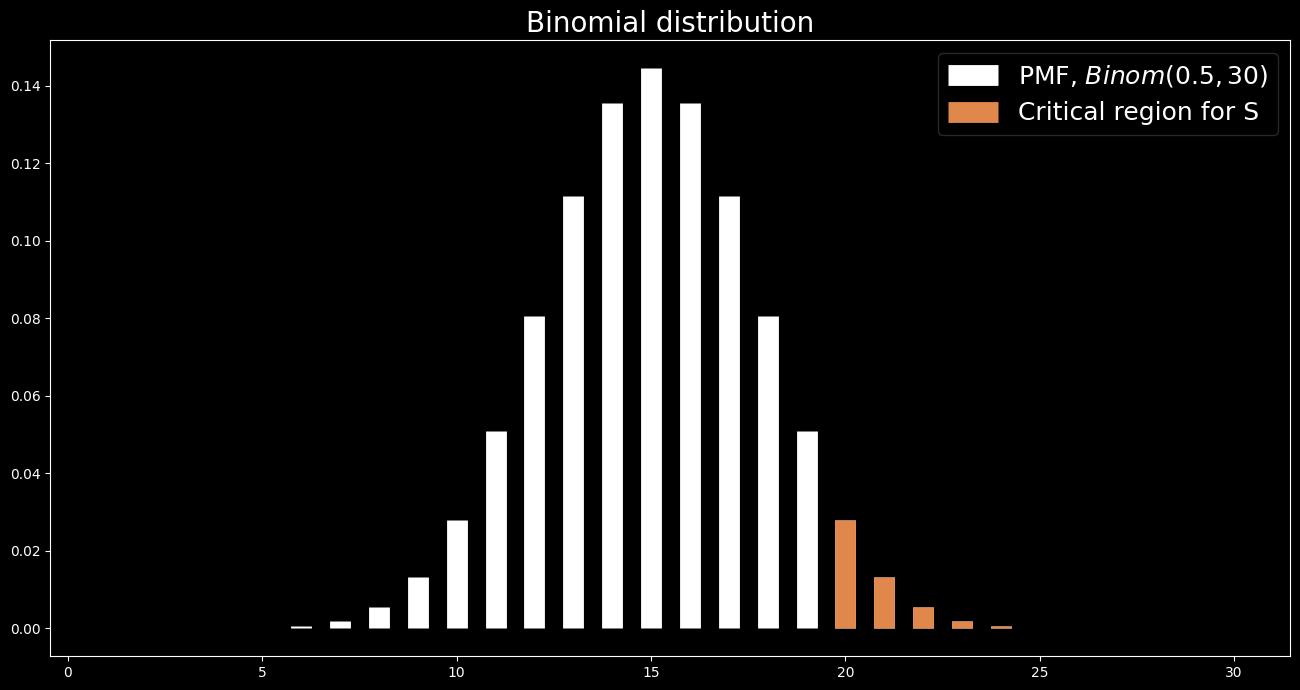

In [8]:
binom_h0 = binom(
    n=30, # количество испытаний
    p=0.5 # вероятность успеха
)
# координата
x_grid = numpy.arange(1, 31)
# высота столбцов на графике
probs = binom_h0.pmf(x_grid)

pyplot.figure(figsize=(16, 8))

# строим вертикальные столбцы от 0 до вероятности
pyplot.vlines(x_grid, 0, probs, linewidth=15.0, color='white', label='PMF, $Binom(0.5, 30)$')
# отдельно изобразим критическую области критерия
crit_reg = x_grid >= 20
pyplot.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=15.0, label='Critical region for S')

pyplot.title('Binomial distribution', fontsize=20)
pyplot.legend(fontsize=18)
pyplot.show()

Видим, например, что $20$ и более успехов случаются достаточно редко. Для принятия решения можно пользоваться правилом инвестируем, если успехов хотя бы 20. Если $H_0$ и верна, то ошибаться, используя это правило, мы будем редко.

## Критерий

Только что мы придумали алгоритм, который по выборке $\xi$ либо признаёт, что мы нашли доказательство в пользу $H_1$, либо говорит, что его не нашли. Соответственно будет либо **отвергать** $H_0$, либо **не отвергать**.

Такой алгоритм называется **критерием**. Представим его как функцию $S$, которая принимает реализацию выборки и возвращает $1$, если нужно отвергнуть 
$H_0$, и $0$ иначе.

$$
    S(\xi) = 
    \begin{cases}
        1, \text{ если отвергаем } \mathsf{H}_0  \
        0, \text{ иначе}
    \end{cases}
$$,

Запишем правило, которое сформулировали выше для нашей задачи:

$$
S(\xi) = \begin{cases}
    1, \text{ если } \sum \xi_i \geqslant 20 \
    0, \text{ иначе}
\end{cases}
$$
 
Обычно сокращают запись и пишут просто правило, по которому отвергаем $H_0$

$$S = \{\sum \xi_i \geqslant 20\}$$

Обозначим $Q = \sum \xi_i$, $С = 20$,тогда критерий принимает вид
$$S = \{Q(\xi) \geqslant C\} $$


Так устроено большинство классических критериев в прикладной статистике, поэтому величинам в нём даны специальные названия. 
$Q$ называется **статистикой критерия**, $C$ — **критическим значением**.

$Q$ может быть любой функцией от выборки, которую вы считаете логичной для проверки гипотезы. В нашем случае это количество успехов, или сумма всех $\xi_i$. Но вы можете выбрать и другие: максимальное значение, сумму первых 5 значений или даже просто первый элемент.

### Поиск критического значения

Снова перепишем наш основной вопрос, только теперь с использованием нашего критерия $S$:

❓ **Насколько часто может быть такое, что при справедливости $H_0$ критерий $S$ отвергает гипотезу?**

Ответ на этот вопрос зависит от критического значения. Сейчас мы взяли его равным $20$, увидев на картинке, что большие отклонения происходят при $H_0$ редко. Но что значит редко и насколько редко, не сказали. Теперь наша цель понять, как выбрать критическое значение $C$, исходя из частоты ошибок нашего критерия.

Выбирая $C$, мы можем либо часто отвергать нулевую гипотезу, когда $C$ мало, либо можем делать это реже, когда $C$ большое. Чтобы выбрать правильное значение, нужно определиться, когда наш критерий ошибается.

$C = 16$

Если отвергать гипотезу при получении хотя бы 16 успешных доставок из 30, то это вряд ли устроит инвесторов. Да, успехов больше половины. Но если в генеральной совокупности вероятность 0.5, то почти в половине случаев мы будем отвергать гипотезу. Критерий *ошибочно возвращает* **1**, то есть это ошибка ***False Positive***.

C = 29

В таком случае будем отвергать гипотезу только при 29 или 30 успехах. Эти значения, конечно, говорят о том, что отклонение от 50% успехов сильное. Но если в генеральной совокупности вероятность, к примеру, 60%, то такие значения будут получаться редко. А ведь такие вероятности тоже устроили бы инвесторов, и мы бы смогли открыть стартап! А с таким критерием мы вряд ли добьёмся этого. Не отвергнуть гипотезу 
, когда она неверна - это тоже ошибка. Она называется **False Negative**, так как критерий вернул 0 ошибочно.

$$False Positive (FP) - H_{0 отвергается, когда она верна}$$

$$False Negative (FN) - H_{0 не отвергается, когда она неверна}$$

В нашей задаче инвесторам важнее *False Positive*. Им очень не хочется попасть в ситуацию, когда им показали доказательство успешности бизнеса, а оказалось, что от большинства заказов отказываются, и компания не получает прибыль. Это приведёт к убыткам. *False Negative* же приведет к тому, что вы упустите успешный бизнес, но инвесторы денег не потеряют.

Поэтому выберем порог, чтобы была удовлетворительной вероятность *False Positive*, или же *False Positive Rate (FPR)*. Для этого надо понять, как часто мы будем отвергать гипотезу, когда верна $H_0$.

Теперь снова переформулируем основной вопрос, полностью с использованием новых терминов, и наконец ответим на него.

❓ **Какой FPR у критерия S для проверки гипотезы $H_0$ vs $H_1$?**

Вспомним моделирование из части 1. Когда $H_0$ верна, чтобы посчитать количество успехов мы проводили $30$ раз подбрасывание монетки с вероятностью орла %0.5$. Количество орлов (то есть успехов) в таком эксперименте имеет распределение, которое называется биномиальным, то есть при $\mu=0.5$ наша статистика имеет биномиальное распределение $Q \sim Binom(0.5, 30)$.

Вычислим FPR для $C=20$

$$FPR = P(S(\xi) = 1|H_0) = P(Q \geq 20|H_0) = P(Q \geq 20|\mu=0.5) = \\ P(Q \geq 20|Q \sim Binom(0.5, 30))$$

Это уже вероятность события при конкретном распределении случайной величины. Его можно посмотреть по таблице или, что удобнее, вычислить в Python. Работе с распределениями в Python будет посвящена часть 3.

$$FPR \approx 0.049$$

Eсли *False Positive Rate* не превышает некоторой константы $\alpha$, то критерий называется **критерием уровня значимости** $\alpha$. В прикладной статистике мы никогда не ставим задачу в формулировке "создать статистический критерий", а ставим только в формулировке "создать статистический критерий уровня значимости $\alpha$". Статистический критерий с $ \alpha= 100$% создать тривиально — достаточно всегда отвергать $H_0$ — поэтому такая постановка не имеет смысла.

Уровень значимости обычно выбирается на основе бизнес-соображений. Он обозначает то, какой риск неправильного принятия положительного решения мы считаем приемлемым. Обычно берут $\alpha=$`0.05`, но если требуется более точное принятие решения, могут выбрать `0.01`, `0.005`, `0.001`. Если же решение не так критично, могут выбрать `0.1`.

Предположим, выбрали значение $\alpha = 0.05$, тогда наш критерий подходит для принятия решений. Воспользуемся критерием $S$: в нашем случае у нас всего лишь 19 успехов, а значит гипотезу $H_0$ мы не отвергаем.



## Часть 3. Статистические функции в Python

В этой части посмотрим, как вывести то, что мы получили в части 2, с помощью Python. А также поймём, как найти подходящее $C$ с помощью Python.

### Биномиальное распределение

Мы выяснили, что статистика $Q$ имеет биномиальное распределение.

Биномиальное распределение $Binom(n,\mu)$ — распределение количества успехов в последовательности из $n$ независимых случайных экспериментов, вероятность успеха в каждом из которых равна $\mu$.

Чтобы работать с распределением, можно создать объект-распределение с помощью библиотеки `scipy.stats`.

In [9]:

binom_h0 = binom(
    n=30, # количество испытаний
    p=0.5 # вероятность успеха
)

### Функция вероятности


Функция вероятности дискретного распределения $p_{\xi}(x)$ — вероятность, с которой $\xi$ принимает значение $x$.

В Python это функция `pmf` (*probability mass function*)

In [10]:
binom_h0.pmf(10)

np.float64(0.02798160072416065)

Изобразим распределение статистики $Q$ при справедливости $H_0$ на графике. Для этого можно передать сразу массив точек, для которых надо рассчитать вероятность.

In [ ]:
# координата
x_grid = numpy.arange(1, 31)
# высота столбцов на графике
probs = binom_h0.pmf(x_grid)

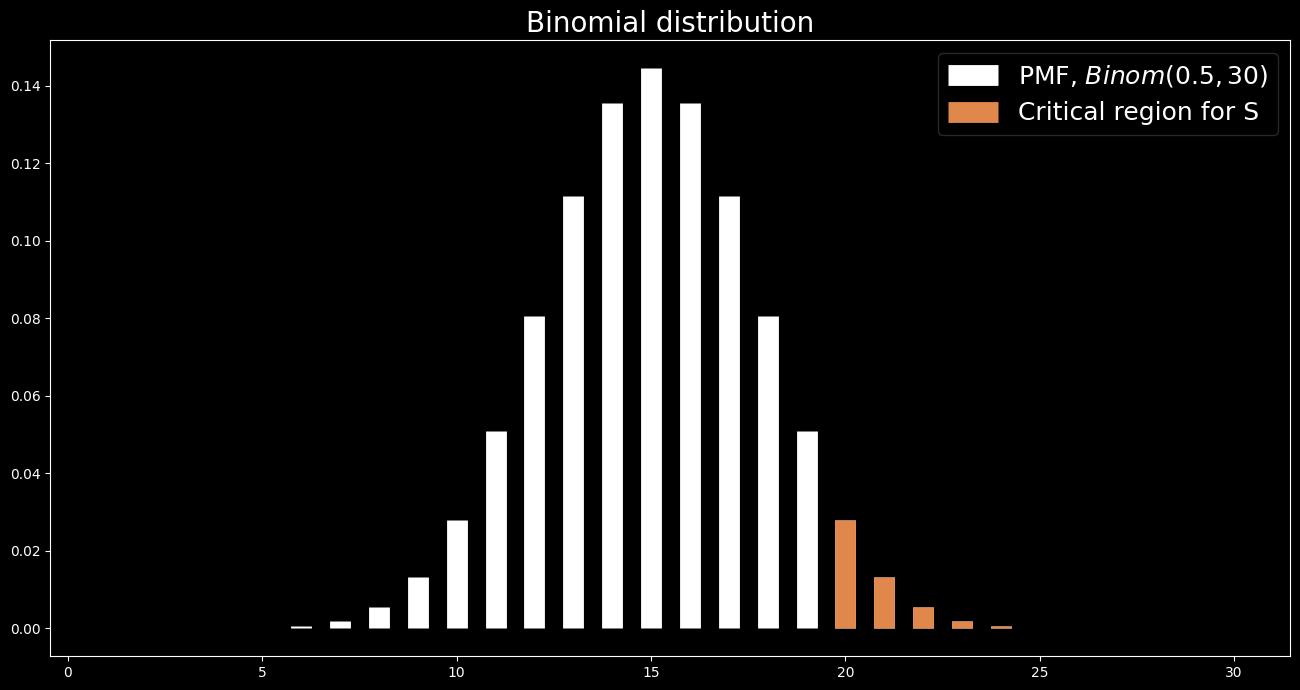

In [12]:
pyplot.figure(figsize=(16, 8))

# строим вертикальные столбцы от 0 до вероятности
pyplot.vlines(x_grid, 0, probs, linewidth=15.0, color='white', label='PMF, $Binom(0.5, 30)$')
# отдельно изобразим критическую области критерия
crit_reg = x_grid >= 20
pyplot.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=15.0, label='Critical region for S')

pyplot.title('Binomial distribution', fontsize=20)
pyplot.legend(fontsize=18)
pyplot.show()


На самом деле уже сейчас мы можем посчитать вероятность попадания в критическую область. Нужно просто просуммировать высоты оранжевых столбцов.

In [13]:
numpy.sum(probs[crit_reg])

np.float64(0.04936857335269457)

Получаем то число, которое было в части 2. Значит мы действительно построили критерий уровня значимости $\alpha=0.05$. Более того, это критерий уровня значимости $\alpha=0.0494$, но такую точность обычно не используют.

А что если бы мы взяли $C=19$?

In [14]:

crit_reg = x_grid >= 19
numpy.sum(probs[crit_reg])

np.float64(0.10024421103298684)

Тогда вероятность ошибки уже даже больше $10$%, что совсем нам не подходит. Видно, что нет такого $C$, чтобы *False Positive Rate* был ровно $5$%.

### Кумулятивная функция распределения

Кумулятивная функция распределения $F_{\xi}(x) = P(\xi \leq x)$

В Python это функция `cdf` (*cumulative distribution function*)

In [15]:

binom_h0.cdf(19)

np.float64(0.9506314266473055)

По строчке выше понятно, что вероятность получить 19 или меньше успехов в нашей задаче $\geq 0.95$. А поскольку $P(\xi \leq 19) + P(\xi \geq 20) =1$, можем вычислить уровень значимости нашего критерия.

In [17]:
1 - binom_h0.cdf(19)

np.float64(0.04936857335269451)

### Квантиль

Чтобы выбрать критическую область для критерия, мы хотели бы найти точку, площадь столбцов справа от которой была бы $5$%. То есть площадь столбцов слева — $95$%. Такая точка называется *квантилью*.

$$u_p(\xi) = \{x|F_{\xi}(x) = p\}$$

Но при 
 и нашем биномиальном распределении, такой точки нет. Мы выяснили, что есть точка, справа от которой площадь 
, а у следующей уже 
. Чтобы определить квантиль в этом случае, модифицируем определение: